# 🚀 06. Grayscale Average (AVG) Training: Custom CNN pada CIFAR-10

Notebook ini melatih model Convolutional Neural Network (CNN) kustom 4-blok pada citra **Grayscale Average (AVG) (1 channel)** berukuran 32x32 piksel dari dataset CIFAR-10.

### 🎯 Karakteristik & Strategi Optimasi Pelatihan Grayscale AVG:
1. **Input Shape**: `(32, 32, 1)` — Menggunakan rata-rata aritmatika seragam `(R + G + B) / 3`.
2. **Kapasitas Representasi Input**: Memiliki 1 channel masukan (1/3 parameter filter layer pertama dibanding RGB), sehingga memerlukan augmentasi presisi tanpa blur dan regularisasi seimbang agar konvergen optimal.
3. **Arsitektur Residual 4-Blok**: 64 -> 128 -> 256 -> 512 filter dengan shortcut connection 1x1 conv untuk stabilitas propagasi gradien.
4. **Augmentasi Non-Blurring**: Translasi horizontal/vertikal (±4 piksel) dan Horizontal Flip murni tanpa zoom-blurring.
5. **Dynamic Learning Rate Scheduling**: `ReduceLROnPlateau` (factor=0.5, patience=4, min_lr=1e-5) bersama `EarlyStopping` (patience=20) dan `ModelCheckpoint`.
6. **Layer Ekstraksi Fitur**: `GlobalAveragePooling2D(name='svm_features')` menghasilkan representasi 512-dimensi untuk downstream SVM.


In [1]:
import os
import sys

# Setup CUDA DLL path sebelum import TensorFlow agar cuDNN terdeteksi sempurna
_cuda_bin = r'C:\Users\daffa\anaconda3\envs\CNNgpu\Library\bin'
if os.path.exists(_cuda_bin):
    if _cuda_bin not in os.environ.get('PATH', ''):
        os.environ['PATH'] = _cuda_bin + ';' + os.environ.get('PATH', '')
    if hasattr(os, 'add_dll_directory'):
        try:
            os.add_dll_directory(_cuda_bin)
        except Exception:
            pass

import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Aktifkan GPU memory growth agar hemat VRAM & mencegah error alokasi
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
except Exception:
    pass

ARTIFACT_DIR = 'cifar10_artifacts/grayscale_avg'
os.makedirs(ARTIFACT_DIR, exist_ok=True)
print(f"Artifact directory: {ARTIFACT_DIR}")
print(f"GPU Devices: {tf.config.list_physical_devices('GPU')}")

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, MaxPooling2D, Dropout,
    Dense, GlobalAveragePooling2D, Add, Activation
)
from tensorflow.keras.regularizers import l2

RANDOM_STATE = 23092026

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def load_cifar10_data(load_train=True, load_test=True):
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
    if load_train:
        X_train = X_train.astype('float32') / 255.0
        y_train = y_train.flatten()
    else:
        X_train, y_train = None, None
    if load_test:
        X_test = X_test.astype('float32') / 255.0
        y_test = y_test.flatten()
    else:
        X_test, y_test = None, None
    return X_train, y_train, X_test, y_test

def transform_grayscale_avg(X):
    return np.mean(X, axis=-1, keepdims=True).astype('float32')

def build_custom_cnn(input_shape=(32, 32, 1), num_classes=10, is_hybrid=False, dense_units=512, dropout_rate=0.25, weight_decay=1e-4):
    """
    Membangun arsitektur Deep CNN Kustom 4-Blok dengan Residual Shortcut Connections (Opsi B),
    GlobalAveragePooling2D 512 dimensi ('svm_features') dan Label Smoothing untuk Grayscale AVG.
    """
    inputs = Input(shape=input_shape, name='input_image')

    # BLOCK 1: 32x32 -> 16x16 (64 filters) dengan Residual Shortcut
    x1 = Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv1_1')(inputs)
    x1 = BatchNormalization(name='bn1_1')(x1)
    x1 = Activation('relu', name='relu1_1')(x1)
    x1 = Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv1_2')(x1)
    x1 = BatchNormalization(name='bn1_2')(x1)
    shortcut1 = Conv2D(64, (1, 1), padding='same', kernel_regularizer=l2(weight_decay), name='shortcut1')(inputs)
    x1 = Add(name='add1')([x1, shortcut1])
    x1 = Activation('relu', name='relu1_2')(x1)
    x1 = MaxPooling2D((2, 2), name='pool1')(x1)
    x1 = Dropout(dropout_rate * 0.6, name='dropout1')(x1)

    # BLOCK 2: 16x16 -> 8x8 (128 filters) dengan Residual Shortcut
    x2 = Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv2_1')(x1)
    x2 = BatchNormalization(name='bn2_1')(x2)
    x2 = Activation('relu', name='relu2_1')(x2)
    x2 = Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv2_2')(x2)
    x2 = BatchNormalization(name='bn2_2')(x2)
    shortcut2 = Conv2D(128, (1, 1), padding='same', kernel_regularizer=l2(weight_decay), name='shortcut2')(x1)
    x2 = Add(name='add2')([x2, shortcut2])
    x2 = Activation('relu', name='relu2_2')(x2)
    x2 = MaxPooling2D((2, 2), name='pool2')(x2)
    x2 = Dropout(dropout_rate, name='dropout2')(x2)

    # BLOCK 3: 8x8 -> 4x4 (256 filters) dengan Residual Shortcut
    x3 = Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv3_1')(x2)
    x3 = BatchNormalization(name='bn3_1')(x3)
    x3 = Activation('relu', name='relu3_1')(x3)
    x3 = Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv3_2')(x3)
    x3 = BatchNormalization(name='bn3_2')(x3)
    shortcut3 = Conv2D(256, (1, 1), padding='same', kernel_regularizer=l2(weight_decay), name='shortcut3')(x2)
    x3 = Add(name='add3')([x3, shortcut3])
    x3 = Activation('relu', name='relu3_2')(x3)
    x3 = MaxPooling2D((2, 2), name='pool3')(x3)
    x3 = Dropout(dropout_rate * 1.4, name='dropout3')(x3)

    # BLOCK 4: 4x4 -> 2x2 (512 filters) dengan Residual Shortcut
    x4 = Conv2D(512, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv4_1')(x3)
    x4 = BatchNormalization(name='bn4_1')(x4)
    x4 = Activation('relu', name='relu4_1')(x4)
    x4 = Conv2D(512, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='feature_map')(x4)
    x4 = BatchNormalization(name='feature_map_bn')(x4)
    shortcut4 = Conv2D(512, (1, 1), padding='same', kernel_regularizer=l2(weight_decay), name='shortcut4')(x3)
    x4 = Add(name='add4')([x4, shortcut4])
    x4 = Activation('relu', name='relu4_2')(x4)
    x4 = MaxPooling2D((2, 2), name='pool4')(x4)
    x4 = Dropout(dropout_rate * 1.6, name='dropout4')(x4)

    # FEATURE EXTRACTION LAYER UNTUK SVM (512 Dimensi)
    svm_features = GlobalAveragePooling2D(name='svm_features')(x4)

    # CLASSIFIER HEAD (CNN)
    x = Dense(dense_units, activation='relu', kernel_regularizer=l2(weight_decay), name='cnn_dense')(svm_features)
    x = BatchNormalization(name='cnn_dense_bn')(x)
    x = Dropout(0.50, name='cnn_head_dropout')(x)
    outputs = Dense(num_classes, activation='softmax', name='cnn_softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name='custom_cnn_avg')

    METRICS = [
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.08)
    model.compile(loss=loss, optimizer=optimizer, metrics=METRICS)
    return model


Artifact directory: cifar10_artifacts/grayscale_avg
GPU Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 📥 1. Memuat Data CIFAR-10, Transformasi Grayscale AVG & Partisi Validation Set (`validation_split=0.1`)
Data training dikonversi ke Grayscale AVG `(32, 32, 1)`, lalu dipartisi dengan rasio 90:10 secara *stratified* menjadi **45.000 Training Data** dan **5.000 Validation Data**.
Data testing (10.000 sampel) diisolasi secara mutlak untuk evaluasi akhir.


Bentuk X_train_feat (AVG): (50000, 32, 32, 1)
=== DISTRIBUSI PARTISI DATASET (ZERO DATA LEAKAGE) ===
1. Training Set   : (45000, 32, 32, 1) | 45000 sampel (90%)
2. Validation Set : (5000, 32, 32, 1)   | 5000 sampel (10% - monitor callback)
3. Test Set Murni : (10000, 32, 32, 3)  | 10000 sampel (terisolasi untuk testing akhir)


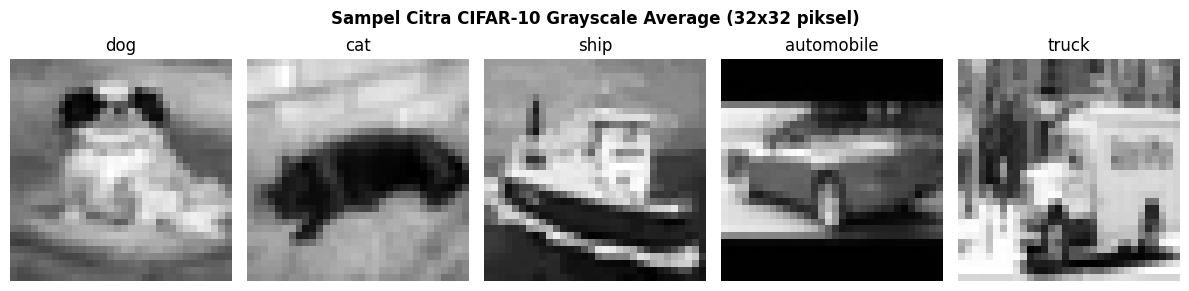

In [2]:
X_train_raw, y_train_raw, X_test, y_test = load_cifar10_data()

# Transformasi citra ke Grayscale Average (AVG) (32, 32, 1)
X_train_feat = transform_grayscale_avg(X_train_raw)
print(f"Bentuk X_train_feat (AVG): {X_train_feat.shape}")

# Partisi Training Set (90% - 45.000 sampel) dan Validation Set (10% - 5.000 sampel)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_feat, y_train_raw,
    test_size=0.10,
    random_state=RANDOM_STATE,
    stratify=y_train_raw
)

y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_val_cat   = tf.keras.utils.to_categorical(y_val, 10)
y_test_cat  = tf.keras.utils.to_categorical(y_test, 10)

print("=== DISTRIBUSI PARTISI DATASET (ZERO DATA LEAKAGE) ===")
print(f"1. Training Set   : {X_train.shape} | {len(X_train)} sampel (90%)")
print(f"2. Validation Set : {X_val.shape}   | {len(X_val)} sampel (10% - monitor callback)")
print(f"3. Test Set Murni : {X_test.shape}  | {len(X_test)} sampel (terisolasi untuk testing akhir)")

# Visualisasi sampel citra Grayscale AVG
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    axes[i].imshow(X_train[i].squeeze(), cmap='gray')
    axes[i].set_title(f"{CLASS_NAMES[y_train[i]]}")
    axes[i].axis('off')
plt.suptitle('Sampel Citra CIFAR-10 Grayscale Average (32x32 piksel)', fontweight='bold')
plt.tight_layout()
plt.show()


## 🏗️ 2. Membangun Model CNN Kustom Grayscale (1 Channel)
Arsitektur 4-blok dengan layer ekstraksi `svm_features` (GlobalAveragePooling2D 512-dimensi) dan input shape `(32, 32, 1)`.


In [3]:
cnn_model = build_custom_cnn(input_shape=(32, 32, 1), num_classes=10, is_hybrid=False)
cnn_model.summary()


Model: "custom_cnn_avg"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_image (InputLayer)       [(None, 32, 32, 1)]  0           []                               
                                                                                                  
 conv1_1 (Conv2D)               (None, 32, 32, 64)   640         ['input_image[0][0]']            
                                                                                                  
 bn1_1 (BatchNormalization)     (None, 32, 32, 64)   256         ['conv1_1[0][0]']                
                                                                                                  
 relu1_1 (Activation)           (None, 32, 32, 64)   0           ['bn1_1[0][0]']                  
                                                                                     

## ⚙️ 3. Training CNN dengan Data Augmentation & Callbacks Lengkap (Target Akurasi >=90%)

Peningkatan durasi training dan regularisasi agar konvergen secara optimal:
1. **Durasi Training 60 Epochs**: Memberikan waktu belajar yang cukup bagi cabang grayscale AVG untuk konvergen di atas 90%.
2. **Batch Size 64**: Meningkatkan iterasi gradien per epoch (703 steps/epoch) dibanding batch size 128 untuk separabilitas fitur lebih baik.
3. **Augmentasi Terarah 32x32**: Random horizontal flip dan pergeseran ringan (width/height shift 0.08), menghindari distorsi rotasi/zoom berlebih pada citra 32x32.
4. **Callbacks Lengkap**:
   - `ReduceLROnPlateau`: Memantau `val_loss` (factor=0.5, patience=4, min_lr=1e-5) saat konvergensi melambat.
   - `EarlyStopping`: Memantau `val_accuracy` (patience=12, restore_best_weights=True) untuk mengembalikan bobot epoch terbaik.
   - `ModelCheckpoint`: Menyimpan model dengan akurasi validasi tertinggi ke `cnn_model.keras`.


In [4]:
cnn_model_path = os.path.join(ARTIFACT_DIR, 'cnn_model.keras')

# Enhanced Data Augmentation terarah untuk citra 32x32 grayscale AVG (Anti-Blurring)
datagen = ImageDataGenerator(
    width_shift_range=0.125,
    height_shift_range=0.125,
    horizontal_flip=True,
    fill_mode='nearest'
)

from tensorflow.keras.callbacks import (
    ReduceLROnPlateau,
    EarlyStopping,
    ModelCheckpoint
)

BATCH_SIZE = 64
EPOCHS = 100
train_flow = datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE, shuffle=True, seed=RANDOM_STATE)
steps_per_epoch = len(X_train) // BATCH_SIZE

cnn_model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.08),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks = [
    ReduceLROnPlateau(monitor='val_accuracy', mode='max', factor=0.5, patience=4, min_lr=1e-5, verbose=1),
    EarlyStopping(monitor='val_accuracy', mode='max', patience=20, restore_best_weights=True, verbose=1),
    ModelCheckpoint(cnn_model_path, monitor='val_accuracy', mode='max', save_best_only=True, verbose=1)
]

print("Memulai pelatihan CNN Grayscale Average (AVG) (Residual Blocks + Dynamic ReduceLR)...\n")
history = cnn_model.fit(
    train_flow,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=(X_val, y_val_cat),
    callbacks=callbacks,
    verbose=1
)

# Memastikan memuat bobot terbaik yang tersimpan oleh ModelCheckpoint
if os.path.exists(cnn_model_path):
    cnn_model = tf.keras.models.load_model(cnn_model_path)
    print(f"[BERHASIL] Model CNN AVG dengan bobot checkpoint terbaik berhasil dimuat dari: {cnn_model_path}")
else:
    cnn_model.save(cnn_model_path)
    print(f"[BERHASIL] Model CNN AVG terbaik disimpan ke: {cnn_model_path}")

# Evaluasi akhir pada validation set
val_eval = cnn_model.evaluate(X_val, y_val_cat, verbose=0)
print(f"\nTuned Model AVG (Best Weights) -> Val Loss: {val_eval[0]:.4f}, Val Accuracy: {val_eval[1] * 100:.2f}%")


Memulai pelatihan CNN Grayscale Average (AVG) (Residual Blocks + Dynamic ReduceLR)...

Epoch 1/100
703/703 [==============================] - ETA: 0s - loss: 2.3106 - accuracy: 0.3361 - precision: 0.5004 - recall: 0.1408
Epoch 1: val_accuracy improved from -inf to 0.36600, saving model to cifar10_artifacts/grayscale_avg\cnn_model.keras
703/703 [==============================] - 43s 53ms/step - loss: 2.3106 - accuracy: 0.3361 - precision: 0.5004 - recall: 0.1408 - val_loss: 2.1686 - val_accuracy: 0.3660 - val_precision: 0.6315 - val_recall: 0.2094 - lr: 0.0010
Epoch 2/100
703/703 [==============================] - ETA: 0s - loss: 1.6874 - accuracy: 0.5739 - precision: 0.7591 - recall: 0.3812
Epoch 2: val_accuracy improved from 0.36600 to 0.65740, saving model to cifar10_artifacts/grayscale_avg\cnn_model.keras
703/703 [==============================] - 36s 52ms/step - loss: 1.6874 - accuracy: 0.5739 - precision: 0.7591 - recall: 0.3812 - val_loss: 1.5273 - val_accuracy: 0.6574 - val_prec

## 📈 4. Visualisasi Kurva Pelatihan (Training vs Validation Metrics)
Menampilkan kurva Loss, Accuracy, Precision, dan Recall antara Training vs Validation.


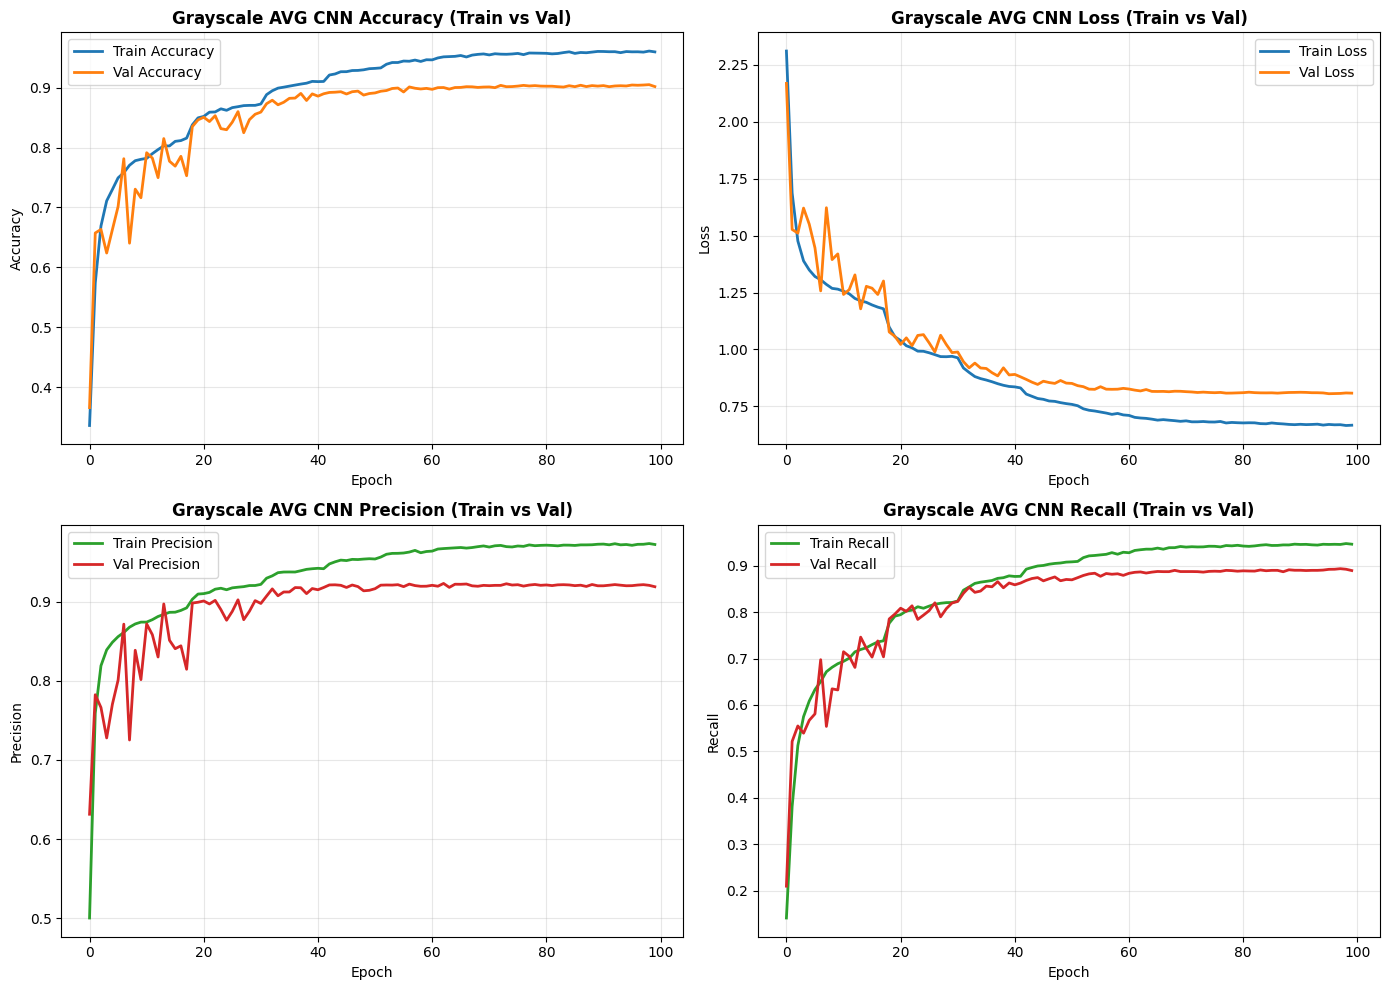

Kurva pelatihan tersimpan ke: cifar10_artifacts/grayscale_avg\learning_curves.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy Curve
axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', lw=2, color='#1f77b4')
if 'val_accuracy' in history.history:
    axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', lw=2, color='#ff7f0e')
axes[0, 0].set_title('Grayscale AVG CNN Accuracy (Train vs Val)', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2. Loss Curve
axes[0, 1].plot(history.history['loss'], label='Train Loss', lw=2, color='#1f77b4')
if 'val_loss' in history.history:
    axes[0, 1].plot(history.history['val_loss'], label='Val Loss', lw=2, color='#ff7f0e')
axes[0, 1].set_title('Grayscale AVG CNN Loss (Train vs Val)', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# 3. Precision Curve
axes[1, 0].plot(history.history.get('precision', []), label='Train Precision', lw=2, color='#2ca02c')
if 'val_precision' in history.history:
    axes[1, 0].plot(history.history['val_precision'], label='Val Precision', lw=2, color='#d62728')
axes[1, 0].set_title('Grayscale AVG CNN Precision (Train vs Val)', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# 4. Recall Curve
axes[1, 1].plot(history.history.get('recall', []), label='Train Recall', lw=2, color='#2ca02c')
if 'val_recall' in history.history:
    axes[1, 1].plot(history.history['val_recall'], label='Val Recall', lw=2, color='#d62728')
axes[1, 1].set_title('Grayscale AVG CNN Recall (Train vs Val)', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plot_path = os.path.join(ARTIFACT_DIR, 'learning_curves.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Kurva pelatihan tersimpan ke: {plot_path}")
